In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Data Preparation

In [83]:
df = pd.read_csv("HouseSale.csv")
df

,_________,____________,____________.1,________ (__),zone Rating,_______ (USD)
0,50.3,5,2,8,1,206042
1,50.9,2,1,21,1,179398
2,53.4,3,1,10,1,187509
3,56.4,5,3,8,1,242866
4,56.6,1,3,16,1,158455
...,...,...,...,...,...,...
356,497.4,5,2,26,5,1107045
357,499.5,3,2,19,5,1092027
358,499.6,1,3,12,5,1102534
359,499.6,5,1,23,5,1070454


In [84]:
df.shape

(361, 6)

In [85]:
df.isna().sum()

_________         0
____________      0
____________.1    0
________ (__)     0
zone Rating       0
_______ (USD)     0
dtype: int64

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   _________       361 non-null    object
 1   ____________    361 non-null    object
 2   ____________.1  361 non-null    object
 3   ________ (__)   361 non-null    object
 4   zone Rating     361 non-null    object
 5   _______ (USD)   361 non-null    object
dtypes: object(6)
memory usage: 17.1+ KB


In [87]:
df = df.apply(pd.to_numeric, errors='coerce')

In [ ]:
avg_max = df.agg(['mean', 'max'])
print(avg_max)

       _________  ____________  ____________.1  ________ (__)  zone Rating  \
mean  277.084444      2.961111        1.969444      16.647222     3.627778   
max   499.600000      5.000000        3.000000      29.000000     5.000000   

      _______ (USD)  
mean     631059.675  
max     1108237.000  


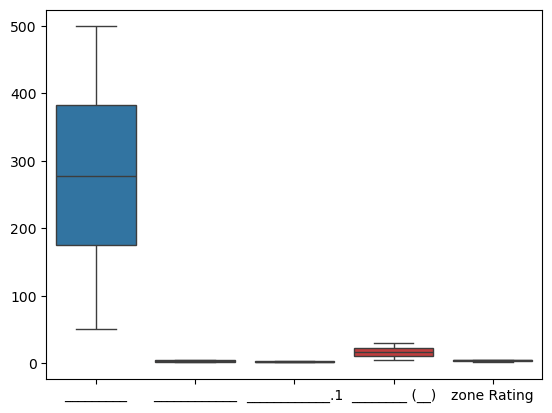

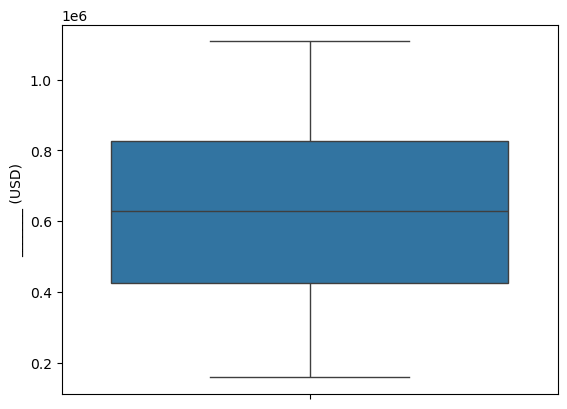

In [ ]:
sns.boxplot(data=df.iloc[:, 0:5])
plt.show()

sns.boxplot(data=df.iloc[:, -1])
plt.show()

<Axes: >

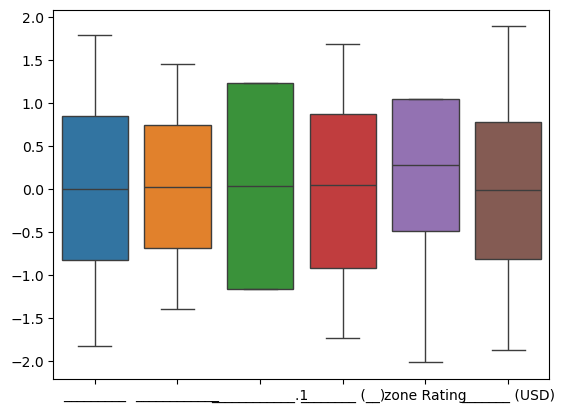

In [95]:
df_numeric = df.select_dtypes(include=['number']).drop(columns=['_______(USD)'], errors='ignore')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)
df_scaled = pd.DataFrame(scaled_data, columns=df_numeric.columns)

sns.boxplot(data=df_scaled)

In [99]:
df_scaled = df_scaled.fillna(df_scaled.mean())

In [100]:
X = df_scaled.iloc[:, :-1]
y = df_scaled.iloc[:, -1]

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)